# CAPMの数理とPython実装
## ベータ・アルファ・証券市場線を理論から導出する

このノートブックは、Zenn記事「CAPMの数理とPython実装」の実装コードです。
記事本文と対応させながら、コードを上から順に実行してください。

### データ
- 銘柄: AAPL, MSFT, AMZN, JPM, JNJ
- ベンチマーク: S&P 500 (^GSPC)
- 期間: 2000-01-01 ~ 2025-12-31

## 0. 環境セットアップ

In [1]:
!pip install yfinance statsmodels -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

## 1. データ取得と超過リターンの計算

In [3]:
# 銘柄とベンチマーク
tickers = ['AAPL', 'MSFT', 'AMZN', 'JPM', 'JNJ']
benchmark = '^GSPC'

# 株価データ取得
data = yf.download(tickers + [benchmark], start='2000-01-01', end='2025-12-31')['Close']

print(f"データ期間: {data.index[0].strftime('%Y-%m-%d')} ~ {data.index[-1].strftime('%Y-%m-%d')}")
print(f"データ件数: {len(data)}")
data.head()

/tmp/ipykernel_3399/2316457837.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers + [benchmark], start='2000-01-01', end='2025-12-31')['Close']
[*********************100%***********************]  6 of 6 completed

データ期間: 2000-01-03 ~ 2025-12-30
データ件数: 6538


Ticker,AAPL,AMZN,JNJ,JPM,MSFT,^GSPC
Date,,,,,,
2000-01-03,0.838496,4.468750,23.282211,22.793854,35.520386,1455.219971
2000-01-04,0.767803,4.096875,22.429840,22.293707,34.320492,1399.420044
2000-01-05,0.779038,3.487500,22.666622,22.156094,34.682354,1402.109985
2000-01-06,0.711621,3.278125,23.376915,22.470640,33.520569,1403.449951
2000-01-07,0.745330,3.478125,24.371338,22.883501,33.958637,1441.469971


In [4]:
# 日次対数リターン
log_returns = np.log(data / data.shift(1)).dropna()

# リスクフリーレート（年率2%を日次に変換）
rf_annual = 0.02
rf_daily = rf_annual / 252

# 超過リターン
excess_returns = log_returns[tickers] - rf_daily
market_excess = log_returns['^GSPC'] - rf_daily

print(f"超過リターン計算完了: {len(excess_returns)} 日分")

超過リターン計算完了: 6537 日分


## 2. ベータの推定

**ベータの定義**: $\beta_i = \frac{\text{Cov}(R_i, R_m)}{\text{Var}(R_m)}$

**回帰モデル**: $R_{i,t} - R_f = \alpha_i + \beta_i(R_{m,t} - R_f) + \epsilon_{i,t}$

### 共分散/分散 と OLS回帰 の両方でベータを計算

In [5]:
betas_formula = {}
betas_ols = {}
alphas_ols = {}
r_squared = {}
ols_results = {}

for ticker in tickers:
    # 方法1: 共分散/分散（数式通り）
    cov_im = np.cov(excess_returns[ticker], market_excess)[0, 1]
    var_m = np.var(market_excess, ddof=1)
    betas_formula[ticker] = cov_im / var_m

    # 方法2: OLS回帰
    X = sm.add_constant(market_excess)
    model = sm.OLS(excess_returns[ticker], X).fit()
    alphas_ols[ticker] = model.params.iloc[0]
    betas_ols[ticker] = model.params.iloc[1]
    r_squared[ticker] = model.rsquared
    ols_results[ticker] = model

# 比較テーブル
comparison = pd.DataFrame({
    'Beta (Cov/Var)': betas_formula,
    'Beta (OLS)': betas_ols,
    'Alpha (OLS)': alphas_ols,
    'R-squared': r_squared
})
print("=== Beta Estimation: Two Methods ===")
print(comparison.round(6))
print()
print("Beta (Cov/Var) と Beta (OLS) が一致することを確認してください。")

=== Beta Estimation: Two Methods ===
      Beta (Cov/Var)  Beta (OLS)  Alpha (OLS)  R-squared
AAPL        1.153155    1.153155     0.000623   0.315456
MSFT        1.092554    1.092554     0.000148   0.498863
AMZN        1.260905    1.260905     0.000325   0.256015
JPM         1.390853    1.390853     0.000104   0.537712
JNJ         0.502998    0.502998     0.000174   0.258825

Beta (Cov/Var) と Beta (OLS) が一致することを確認してください。


### 図1: 各銘柄 vs S&P 500 超過リターン散布図 + 回帰直線

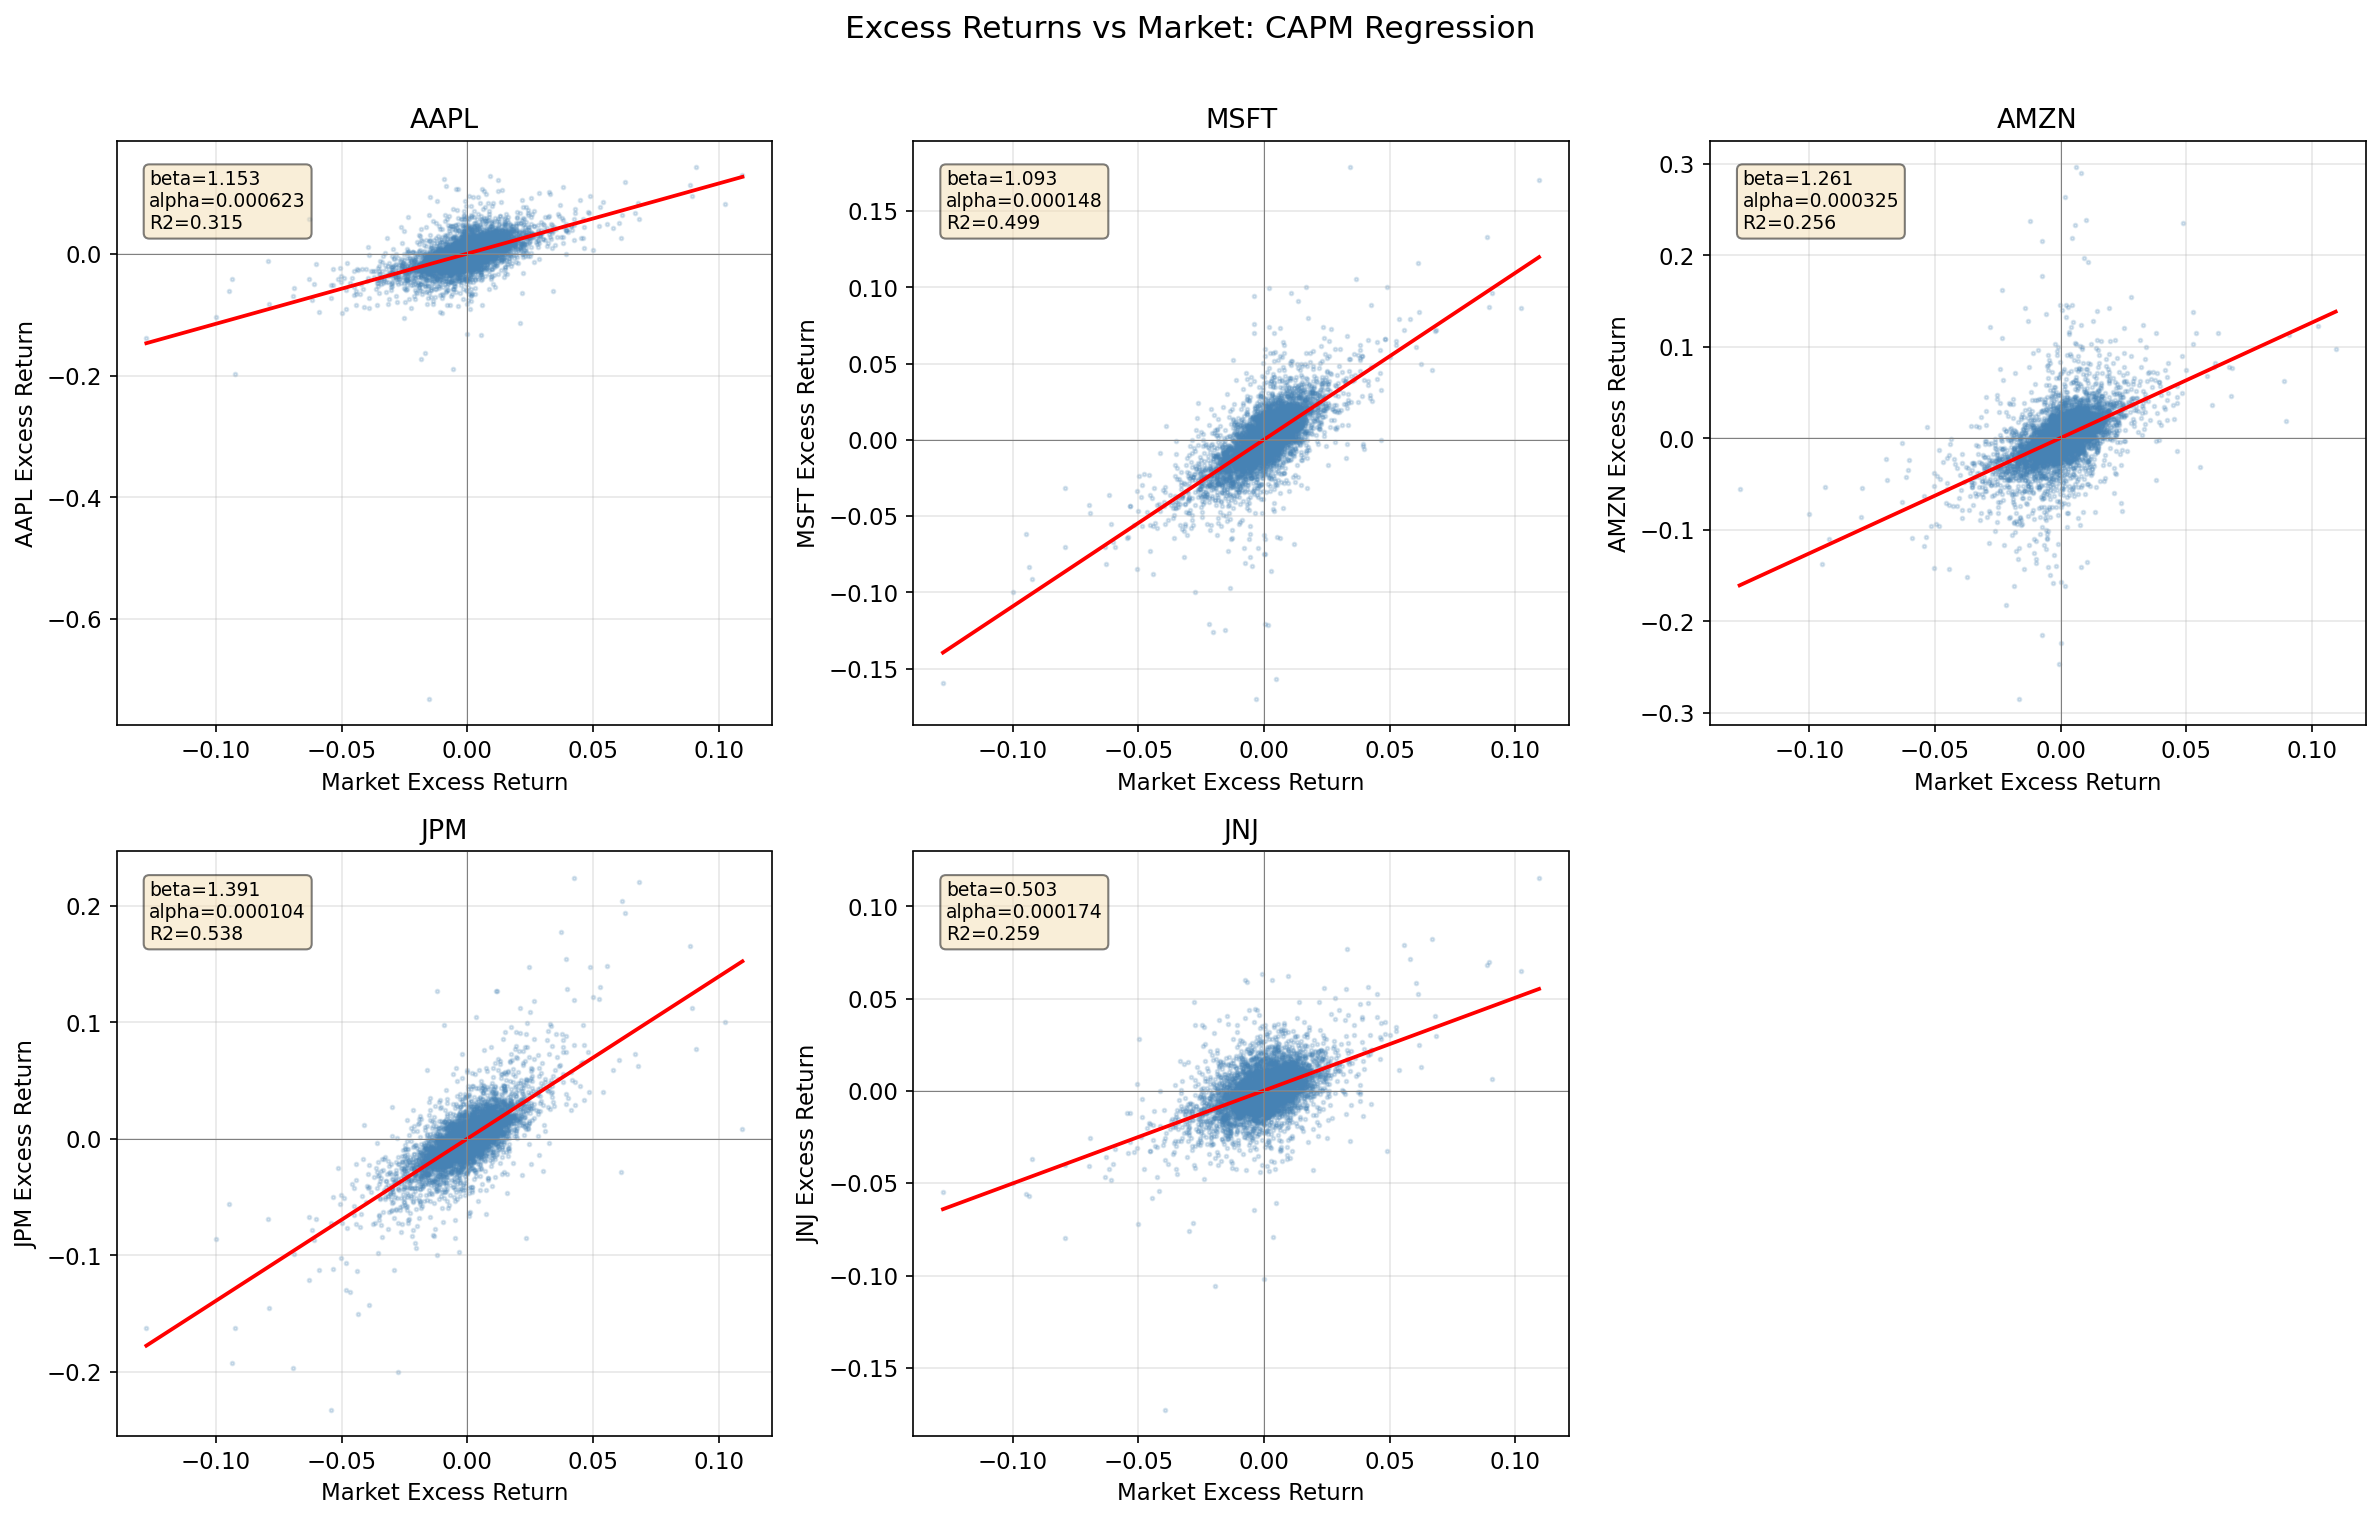

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]

    # 散布図
    ax.scatter(market_excess, excess_returns[ticker],
               alpha=0.2, s=3, color='steelblue')

    # 回帰直線
    x_line = np.linspace(market_excess.min(), market_excess.max(), 100)
    y_line = alphas_ols[ticker] + betas_ols[ticker] * x_line
    ax.plot(x_line, y_line, 'r-', linewidth=1.8)

    # アノテーション
    beta_val = betas_ols[ticker]
    alpha_val = alphas_ols[ticker]
    r2_val = r_squared[ticker]
    ax.set_title(f'{ticker}', fontsize=13)
    ax.text(0.05, 0.95,
            f'beta={beta_val:.3f}\nalpha={alpha_val:.6f}\nR2={r2_val:.3f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.set_xlabel('Market Excess Return')
    ax.set_ylabel(f'{ticker} Excess Return')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)

# 空のsubplotを非表示
axes[5].set_visible(False)

plt.suptitle('Excess Returns vs Market: CAPM Regression', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 図2: ベータ値の棒グラフ

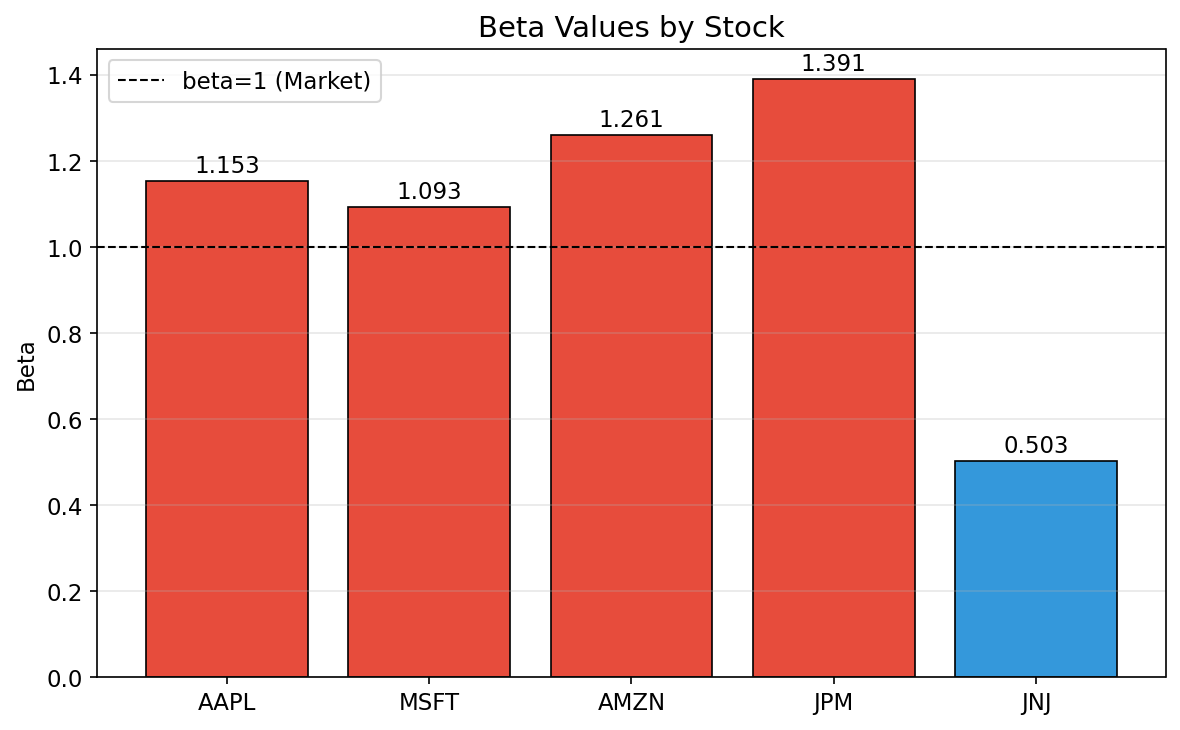

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
beta_values = [betas_ols[t] for t in tickers]
colors = ['#e74c3c' if b > 1 else '#3498db' for b in beta_values]

ax.bar(tickers, beta_values, color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(y=1, color='black', linestyle='--', linewidth=1, label='beta=1 (Market)')
ax.set_title('Beta Values by Stock', fontsize=14)
ax.set_ylabel('Beta')
ax.legend()
for i, v in enumerate(beta_values):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 3. アルファの解釈

**ジェンセンのアルファ**: $\alpha_i = (R_i - R_f) - \beta_i(R_m - R_f)$

- $\alpha > 0$: CAPMの予測よりも高いリターン（アウトパフォーム）
- $\alpha = 0$: CAPMが成立
- $\alpha < 0$: CAPMの予測よりも低いリターン（アンダーパフォーム）

### アルファの統計的検定

In [8]:
alpha_results = pd.DataFrame({
    'Alpha (daily)': {t: ols_results[t].params.iloc[0] for t in tickers},
    'Alpha (annualized)': {t: ols_results[t].params.iloc[0] * 252 for t in tickers},
    't-statistic': {t: ols_results[t].tvalues.iloc[0] for t in tickers},
    'p-value': {t: ols_results[t].pvalues.iloc[0] for t in tickers},
    'Significant (5%)': {t: ols_results[t].pvalues.iloc[0] < 0.05 for t in tickers}
})
print("=== Jensen's Alpha Test ===")
print(alpha_results.round(6))

=== Jensen's Alpha Test ===
      Alpha (daily)  Alpha (annualized)  t-statistic   p-value  \
AAPL       0.000623            0.156910     2.425703  0.015306   
MSFT       0.000148            0.037203     0.892177  0.372331   
AMZN       0.000325            0.081939     1.001064  0.316833   
JPM        0.000104            0.026280     0.535141  0.592570   
JNJ        0.000174            0.043903     1.354493  0.175626   

      Significant (5%)  
AAPL              True  
MSFT             False  
AMZN             False  
JPM              False  
JNJ              False  


### 図3: アルファ値（95%信頼区間）

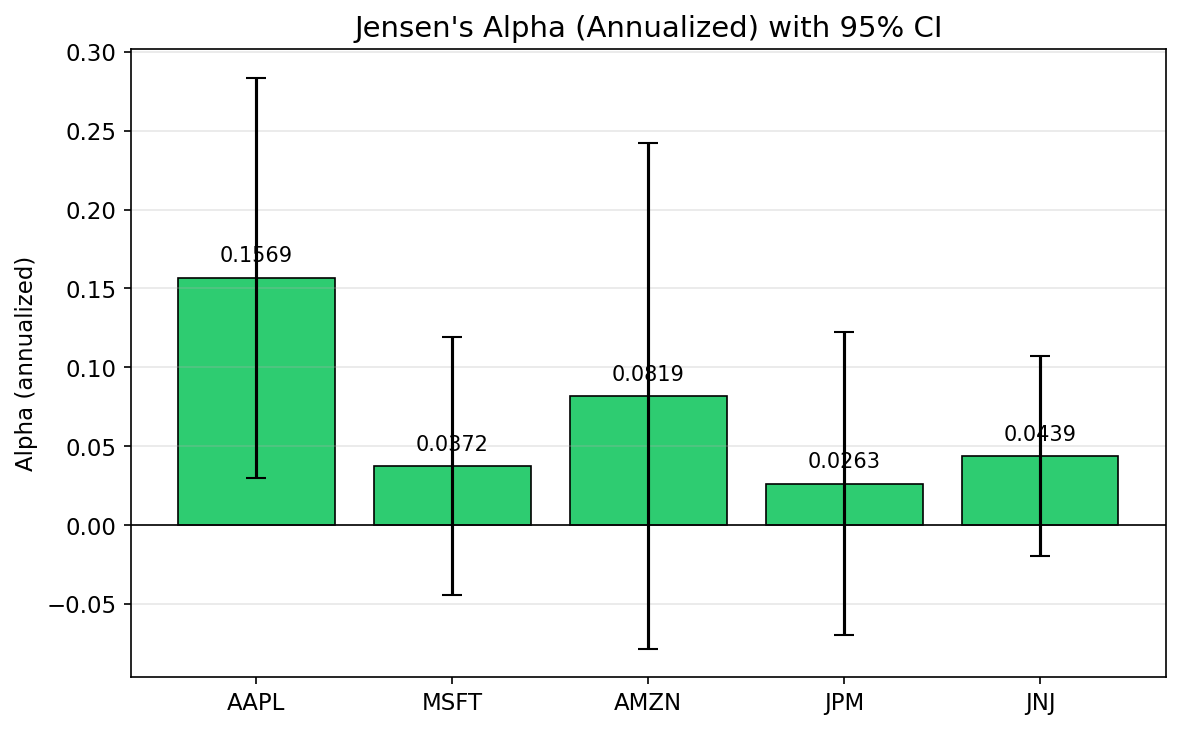

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
alpha_annual = [ols_results[t].params.iloc[0] * 252 for t in tickers]
ci_lower = [ols_results[t].conf_int().iloc[0, 0] * 252 for t in tickers]
ci_upper = [ols_results[t].conf_int().iloc[0, 1] * 252 for t in tickers]
errors = [[a - l for a, l in zip(alpha_annual, ci_lower)],
          [u - a for a, u in zip(alpha_annual, ci_upper)]]

colors = ['#2ecc71' if a > 0 else '#e74c3c' for a in alpha_annual]
ax.bar(tickers, alpha_annual, color=colors, edgecolor='black', linewidth=0.8,
       yerr=errors, capsize=5, error_kw={'linewidth': 1.5})
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_title("Jensen's Alpha (Annualized) with 95% CI", fontsize=14)
ax.set_ylabel('Alpha (annualized)')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(alpha_annual):
    ax.text(i, v + (0.01 if v >= 0 else -0.02), f'{v:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 4. 証券市場線（Security Market Line: SML）

**SMLの式**: $E[R_i] = R_f + \beta_i (E[R_m] - R_f)$

- 傾き: マーケットリスクプレミアム $E[R_m] - R_f$
- 切片: リスクフリーレート $R_f$

### 図4: 証券市場線（SML）

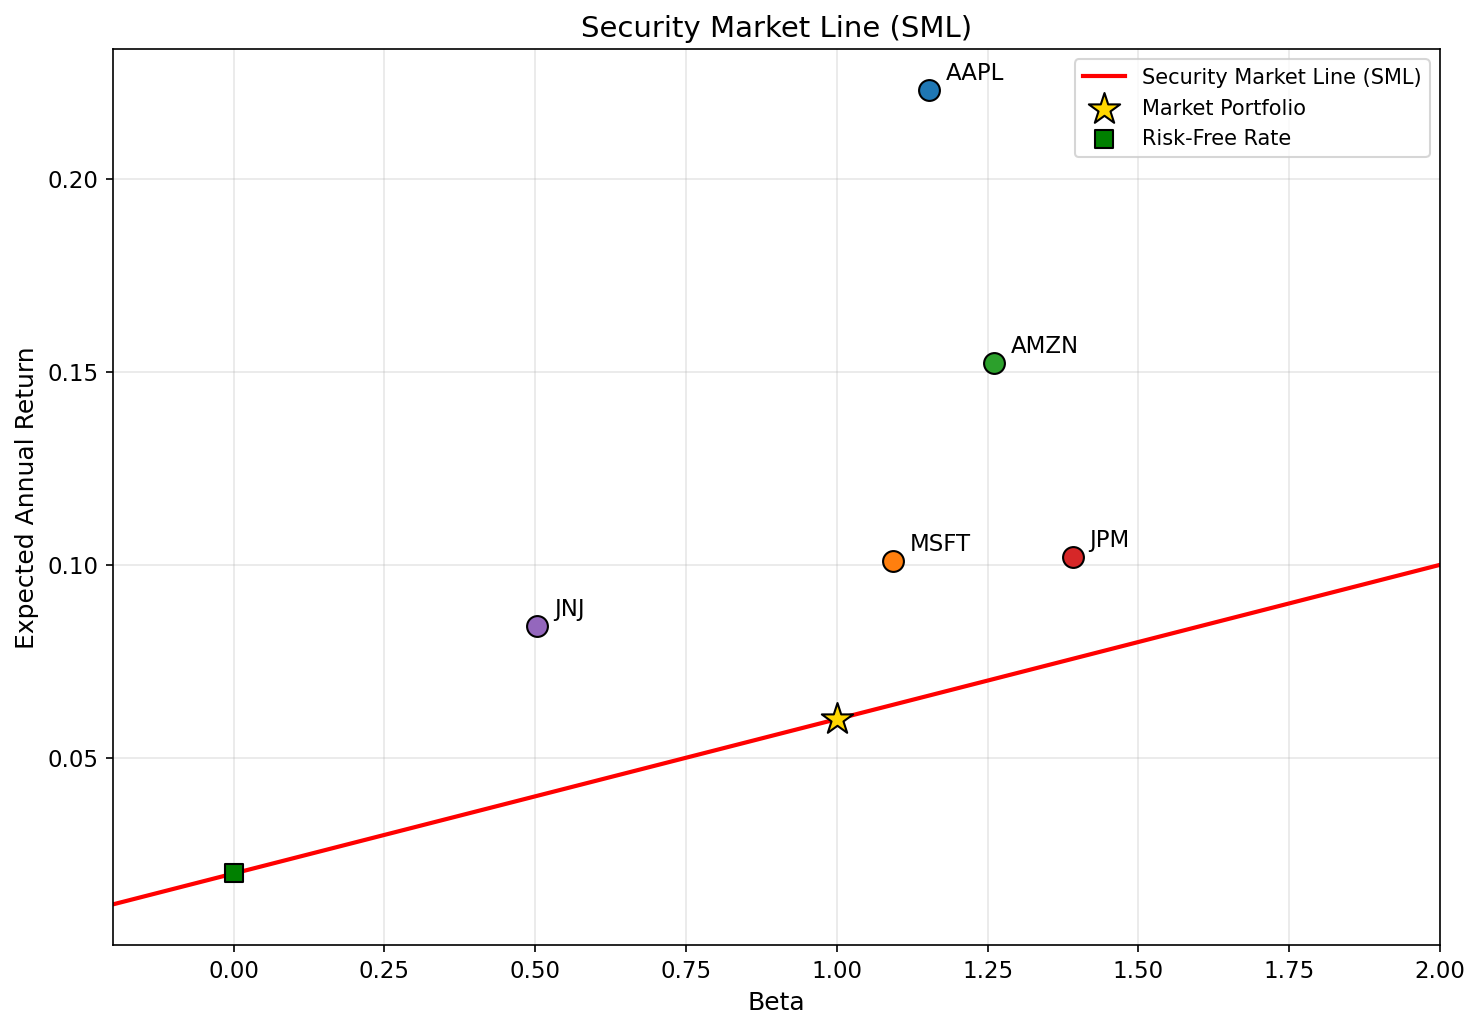

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))

# SML直線
market_return_annual = log_returns['^GSPC'].mean() * 252
beta_range = np.linspace(-0.2, 2.0, 100)
sml = rf_annual + beta_range * (market_return_annual - rf_annual)
ax.plot(beta_range, sml, 'r-', linewidth=2, label='Security Market Line (SML)')

# 各銘柄のプロット
actual_returns = {t: log_returns[t].mean() * 252 for t in tickers}
for ticker in tickers:
    ax.scatter(betas_ols[ticker], actual_returns[ticker],
               s=100, zorder=5, edgecolors='black', linewidths=1)
    ax.annotate(ticker,
                (betas_ols[ticker], actual_returns[ticker]),
                textcoords="offset points", xytext=(8, 5), fontsize=11)

# 市場ポートフォリオ（beta=1）
ax.scatter(1.0, market_return_annual, marker='*', s=250, c='gold',
           edgecolors='black', linewidths=1, zorder=5, label='Market Portfolio')

# リスクフリーレート（beta=0）
ax.scatter(0, rf_annual, marker='s', s=80, c='green',
           edgecolors='black', linewidths=1, zorder=5, label='Risk-Free Rate')

ax.set_title('Security Market Line (SML)', fontsize=14)
ax.set_xlabel('Beta', fontsize=12)
ax.set_ylabel('Expected Annual Return', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.2, 2.0)
plt.tight_layout()
plt.show()

## 5. 系統的リスクと非系統的リスク

**リスク分解**: $\sigma_i^2 = \beta_i^2 \sigma_m^2 + \sigma_{\epsilon_i}^2$

- $\beta_i^2 \sigma_m^2$: 系統的リスク（分散不可能）
- $\sigma_{\epsilon_i}^2$: 非系統的リスク（分散可能）
- $R^2 = \beta_i^2 \sigma_m^2 / \sigma_i^2$

### リスク分解テーブル

In [11]:
var_market = market_excess.var() * 252

risk_decomposition = pd.DataFrame({
    'Total Risk (Var)': {t: excess_returns[t].var() * 252 for t in tickers},
    'Systematic Risk': {t: betas_ols[t]**2 * var_market for t in tickers},
    'Unsystematic Risk': {t: excess_returns[t].var() * 252 - betas_ols[t]**2 * var_market for t in tickers},
    'R-squared': {t: r_squared[t] for t in tickers}
})
print("=== Risk Decomposition ===")
print(risk_decomposition.round(4))

=== Risk Decomposition ===
      Total Risk (Var)  Systematic Risk  Unsystematic Risk  R-squared
AAPL            0.1585           0.0500             0.1085     0.3155
MSFT            0.0900           0.0449             0.0451     0.4989
AMZN            0.2335           0.0598             0.1737     0.2560
JPM             0.1353           0.0727             0.0625     0.5377
JNJ             0.0368           0.0095             0.0272     0.2588


### 図5: リスク分解（積み上げ棒グラフ）

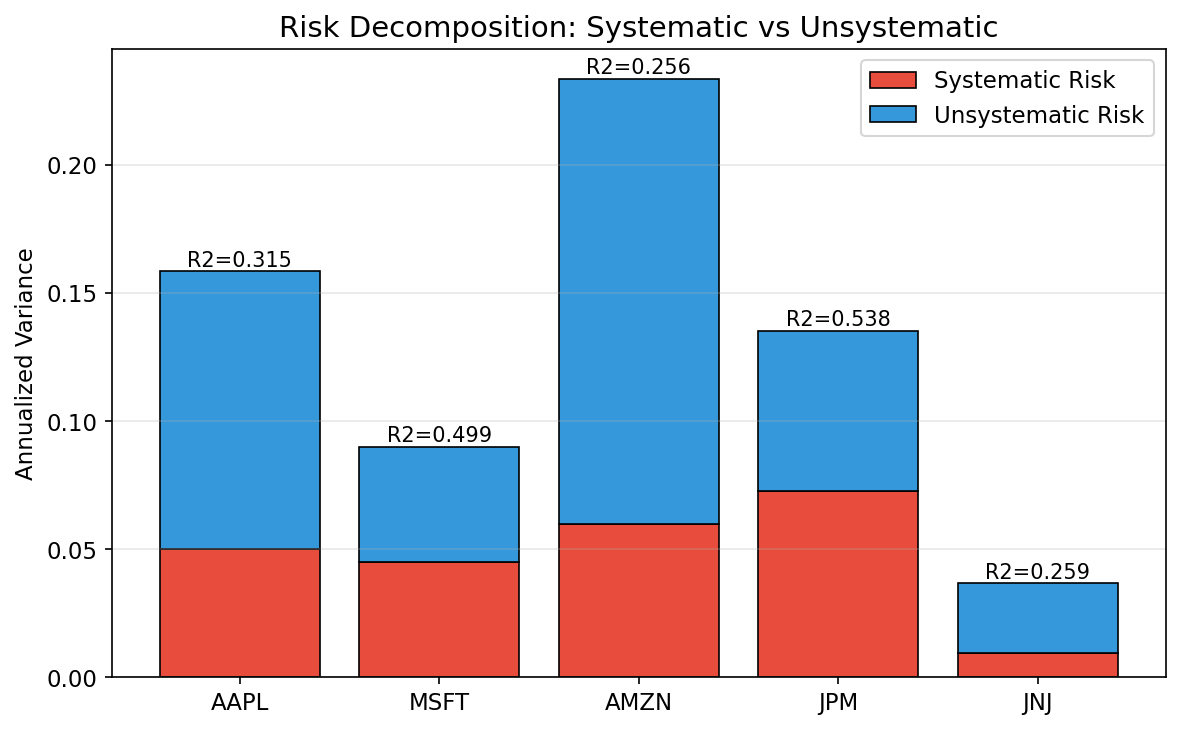

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
sys_risk = [betas_ols[t]**2 * var_market for t in tickers]
unsys_risk = [excess_returns[t].var() * 252 - betas_ols[t]**2 * var_market for t in tickers]

ax.bar(tickers, sys_risk, label='Systematic Risk', color='#e74c3c', edgecolor='black', linewidth=0.8)
ax.bar(tickers, unsys_risk, bottom=sys_risk, label='Unsystematic Risk',
       color='#3498db', edgecolor='black', linewidth=0.8)

ax.set_title('Risk Decomposition: Systematic vs Unsystematic', fontsize=14)
ax.set_ylabel('Annualized Variance')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for i, t in enumerate(tickers):
    total = sys_risk[i] + unsys_risk[i]
    ax.text(i, total + 0.002, f'R2={r_squared[t]:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### 図6: 銘柄数 vs ポートフォリオリスク（分散投資の効果）

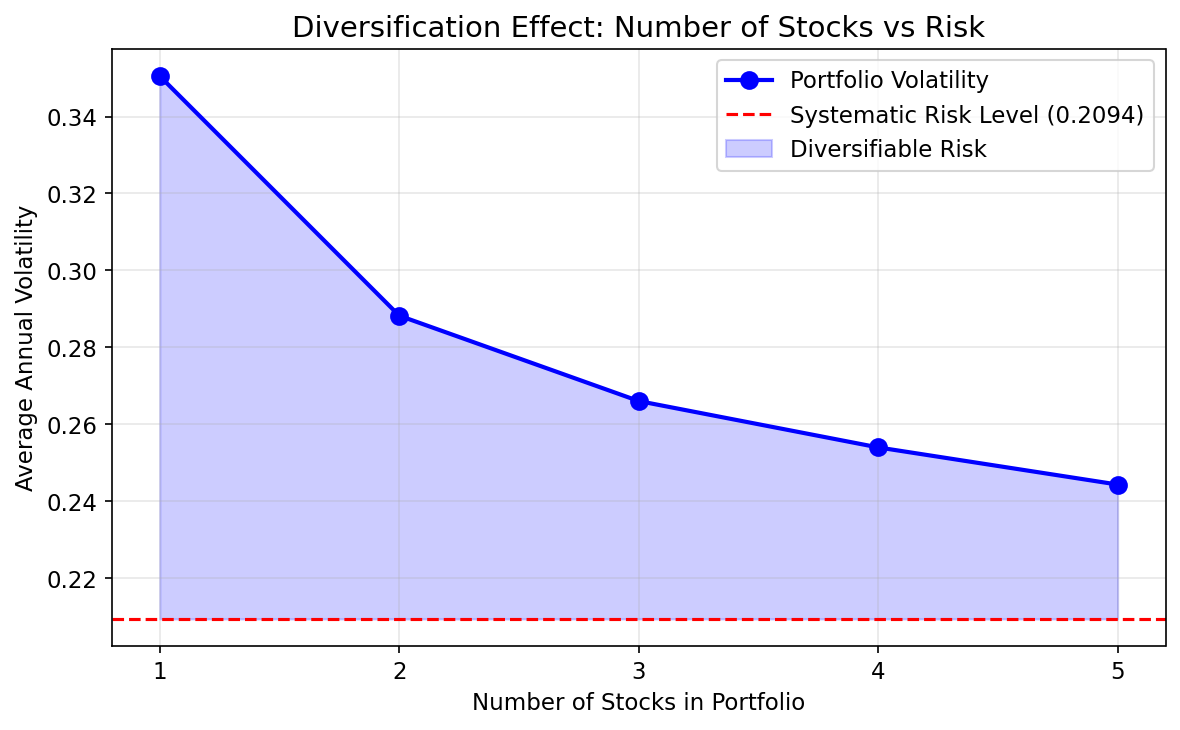

In [13]:
np.random.seed(42)

n_simulations = 1000
max_stocks = len(tickers)
avg_risks = []

for n in range(1, max_stocks + 1):
    risks = []
    for _ in range(n_simulations):
        selected = np.random.choice(tickers, n, replace=False)
        selected_returns = log_returns[list(selected)]
        port_return = selected_returns.mean(axis=1)
        risk = port_return.std() * np.sqrt(252)
        risks.append(risk)
    avg_risks.append(np.mean(risks))

# 系統的リスクの水準
avg_beta = np.mean(list(betas_ols.values()))
systematic_vol = np.sqrt(var_market) * avg_beta

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, max_stocks + 1), avg_risks, 'bo-', linewidth=2, markersize=8,
        label='Portfolio Volatility')
ax.axhline(y=systematic_vol, color='red', linestyle='--', linewidth=1.5,
           label=f'Systematic Risk Level ({systematic_vol:.4f})')
ax.fill_between(range(1, max_stocks + 1), systematic_vol, avg_risks,
                alpha=0.2, color='blue', label='Diversifiable Risk')

ax.set_title('Diversification Effect: Number of Stocks vs Risk', fontsize=14)
ax.set_xlabel('Number of Stocks in Portfolio')
ax.set_ylabel('Average Annual Volatility')
ax.legend()
ax.set_xticks(range(1, max_stocks + 1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 補足: statsmodels OLS回帰の詳細結果

各銘柄の回帰結果のサマリーを表示します。

In [14]:
for ticker in tickers:
    print(f"{'='*60}")
    print(f"  {ticker}")
    print(f"{'='*60}")
    print(ols_results[ticker].summary().tables[1])
    print()

  AAPL
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.000      2.426      0.015       0.000       0.001
^GSPC          1.1532      0.021     54.877      0.000       1.112       1.194

  MSFT
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001      0.000      0.892      0.372      -0.000       0.000
^GSPC          1.0926      0.014     80.656      0.000       1.066       1.119

  AMZN
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      1.001      0.317      -0.000       0.001
^GSPC          1.2609      0.027     47.421      0.000       1.209       1.313

  JPM
                 coef 